# Heart Failure Demo

In [1]:
# Load the dataset and apply the basic cleanup steps.
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

FIGURE_SIZE = (4, 4)   
DATA_PATH = Path('data/heart_failure_clinical_records_5000.csv')
df = pd.read_csv(DATA_PATH)

clean_df = df.drop_duplicates().copy()
if clean_df.isnull().sum().sum() > 0:
    clean_df = clean_df.dropna().reset_index(drop=True)

print(f'Raw dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'After duplicate removal: {clean_df.shape[0]} rows, {clean_df.shape[1]} columns')

Raw dataset loaded: 5000 rows, 13 columns
After duplicate removal: 1320 rows, 13 columns


In [2]:
# Split the data and standardize the continuous features.
feature_columns = [column for column in clean_df.columns if column != 'DEATH_EVENT']
continuous_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

def train_test_split_from_scratch(X, y, test_size=0.2, random_state=42):
    # Fixed randomness makes the split reproducible.
    rng = np.random.default_rng(random_state)
    indices = np.arange(X.shape[0])
    rng.shuffle(indices)
    test_count = int(np.ceil(X.shape[0] * test_size))
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def fit_standardizer(train_df, columns):
    # Save the scaling values from the training set.
    means = train_df[columns].mean()
    stds = train_df[columns].std(ddof=0).replace(0, 1.0)
    return means, stds

def apply_standardizer(frame, columns, means, stds):
    # Scale test rows and manual inputs with the training-set statistics.
    transformed = frame.copy()
    transformed[columns] = (transformed[columns] - means) / stds
    return transformed

X_df = clean_df[feature_columns].copy()
y = clean_df['DEATH_EVENT'].to_numpy(dtype=float)

X_train_raw, X_test_raw, y_train, y_test = train_test_split_from_scratch(
    X_df.to_numpy(dtype=float),
    y,
    test_size=0.2,
    random_state=42
)

X_train_df = pd.DataFrame(X_train_raw, columns=feature_columns)
X_test_df = pd.DataFrame(X_test_raw, columns=feature_columns)

train_means, train_stds = fit_standardizer(X_train_df, continuous_features)
X_train_processed = apply_standardizer(X_train_df, continuous_features, train_means, train_stds)
X_test_processed = apply_standardizer(X_test_df, continuous_features, train_means, train_stds)

feature_mins = clean_df[feature_columns].min()
feature_maxs = clean_df[feature_columns].max()


In [3]:
# Define and train the logistic regression model from scratch.
# ChatGPT was used to outline the class skeleton and function descriptions, 
# but the implementation and debugging were done by hand.
class LogisticRegression:
    def __init__(self, learning_rate=0.03, epochs=5000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0

    @staticmethod
    def sigmoid(z):
        # Clip extreme values so the exponential stays numerically stable.
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        # Train the weights with gradient descent.
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0

        for _ in range(self.epochs):
            linear_output = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear_output)
            dw = np.dot(X.T, (predictions - y)) / n_samples
            db = np.mean(predictions - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

X_train = X_train_processed.to_numpy(dtype=float)
X_test  = X_test_processed.to_numpy(dtype=float)

model = LogisticRegression(learning_rate=0.03, epochs=5000)
model.fit(X_train, y_train)

print('Model training complete.')


Model training complete.


In [4]:
# Compute the main evaluation metrics on the test set.
def confusion_matrix_binary(y_true, y_pred):
    # Return the four basic counts once so the other metrics can reuse them.
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tn, fp, fn, tp

def accuracy_score_binary(y_true, y_pred):
    # Accuracy is the overall fraction of correct predictions.
    return float(np.mean(y_true == y_pred))

def precision_score_binary(y_true, y_pred):
    # Precision asks how many predicted positives were actually correct.
    _, fp, _, tp = confusion_matrix_binary(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) else 0.0

def recall_score_binary(y_true, y_pred):
    # Recall asks how many real positives the model successfully found.
    _, _, fn, tp = confusion_matrix_binary(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) else 0.0

def f1_score_binary(y_true, y_pred):
    # F1 balances precision and recall in a single number.
    precision = precision_score_binary(y_true, y_pred)
    recall = recall_score_binary(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

def roc_curve_points(y_true, y_scores):
    # Sweep across score thresholds to build the ROC curve.
    thresholds = np.unique(y_scores)[::-1]
    thresholds = np.concatenate(([1.0], thresholds, [0.0]))
    fprs = []
    tprs = []
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix_binary(y_true, y_pred)
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        tpr = tp / (tp + fn) if (tp + fn) else 0.0
        fprs.append(fpr)
        tprs.append(tpr)
    return np.array(fprs), np.array(tprs)

def roc_auc_score_binary(y_true, y_scores):
    # AUC summarizes how well the model separates the two classes overall.
    fprs, tprs = roc_curve_points(y_true, y_scores)
    order = np.argsort(fprs)
    return float(np.trapezoid(tprs[order], fprs[order]))

X_test = X_test_processed.to_numpy(dtype=float)
test_probabilities = model.predict_proba(X_test)
test_predictions = model.predict(X_test, threshold=0.5)

accuracy = accuracy_score_binary(y_test, test_predictions)
precision = precision_score_binary(y_test, test_predictions)
recall = recall_score_binary(y_test, test_predictions)
f1_score = f1_score_binary(y_test, test_predictions)
roc_auc = roc_auc_score_binary(y_test, test_probabilities)
tn, fp, fn, tp = confusion_matrix_binary(y_test, test_predictions)

print(f'Model accuracy on test set: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 score: {f1_score:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Confusion matrix -> TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
print('Tuned settings: learning_rate=0.03, epochs=5000, threshold=0.50')


Model accuracy on test set: 0.8712
Precision: 0.7846
Recall: 0.7183
F1 score: 0.7500
ROC-AUC: 0.8872
Confusion matrix -> TN: 179, FP: 14, FN: 20, TP: 51
Tuned settings: learning_rate=0.03, epochs=5000, threshold=0.50


In [5]:
# Show which features matter most in the scratch model.
coefficient_table = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model.weights,
    'absolute_value': np.abs(model.weights)
}).sort_values('absolute_value', ascending=False)

print(coefficient_table[['feature', 'coefficient']].to_string(index=False))


                 feature  coefficient
                    time    -1.427391
       ejection_fraction    -0.734316
        serum_creatinine     0.577266
                     age     0.466992
            serum_sodium    -0.361814
creatinine_phosphokinase     0.267842
                 anaemia     0.160521
               platelets    -0.147418
                     sex    -0.127439
     high_blood_pressure     0.127387
                 smoking     0.106903
                diabetes     0.001462


In [6]:
# Compare the scratch model against scikit-learn logistic regression.
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

sklearn_model = SklearnLogisticRegression(max_iter=5000, random_state=42)
sklearn_model.fit(X_train, y_train)
sklearn_probabilities = sklearn_model.predict_proba(X_test)[:, 1]
sklearn_predictions = sklearn_model.predict(X_test)

comparison_table = pd.DataFrame([
    {
        'model': 'Scratch logistic regression',
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'roc_auc': roc_auc,
    },
    {
        'model': 'scikit-learn logistic regression',
        'accuracy': accuracy_score_binary(y_test, sklearn_predictions),
        'precision': precision_score_binary(y_test, sklearn_predictions),
        'recall': recall_score_binary(y_test, sklearn_predictions),
        'f1_score': f1_score_binary(y_test, sklearn_predictions),
        'roc_auc': roc_auc_score_binary(y_test, sklearn_probabilities),
    }
])

print(comparison_table.to_string(index=False))


                           model  accuracy  precision   recall  f1_score  roc_auc
     Scratch logistic regression  0.871212   0.784615 0.718310  0.750000 0.887214
scikit-learn logistic regression  0.867424   0.781250 0.704225  0.740741 0.889185


In [7]:
# Prepare one demo patient and generate a probability prediction.
def validate_patient_input(patient_dict):
    # Flag invalid values and warn when inputs fall outside the dataset range.
    errors = []
    warnings = []
    binary_features = {'anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking'}

    for feature in binary_features:
        if patient_dict[feature] not in (0, 1):
            errors.append(f'{feature} must be 0 or 1.')

    for feature, value in patient_dict.items():
        if feature not in binary_features and value < 0:
            errors.append(f'{feature} must be non-negative.')

    for feature, value in patient_dict.items():
        if value < feature_mins[feature] or value > feature_maxs[feature]:
            warnings.append(
                f"{feature} is outside the training data range ({feature_mins[feature]:.2f} to {feature_maxs[feature]:.2f})."
            )

    return errors, warnings

def prepare_single_patient(patient_dict, feature_columns, continuous_features, means, stds):
    # Turn the demo dictionary into a one-row table that matches the training data.
    patient_df = pd.DataFrame([patient_dict], columns=feature_columns)
    patient_df = apply_standardizer(patient_df, continuous_features, means, stds)
    return patient_df.to_numpy(dtype=float)

def predict_patient_risk(patient_dict, threshold=0.5):
    # Return both the raw probability and the thresholded class prediction.
    errors, warnings = validate_patient_input(patient_dict)
    if errors:
        raise ValueError(' '.join(errors))
    patient_array = prepare_single_patient(
        patient_dict,
        feature_columns,
        continuous_features,
        train_means,
        train_stds
    )
    probability = float(model.predict_proba(patient_array)[0])
    prediction = int(probability >= threshold)
    return probability, prediction, warnings

demo_patient = {
    'age': 75.0,
    'anaemia': 0,
    'creatinine_phosphokinase': 250.0,
    'diabetes': 1,
    'ejection_fraction': 35.0,
    'high_blood_pressure': 1,
    'platelets': 250000.0,
    'serum_creatinine': 1.3,
    'serum_sodium': 137.0,
    'sex': 1,
    'smoking': 0,
    'time': 120.0
}

probability, prediction, warnings = predict_patient_risk(demo_patient)

print('Demo patient:')
print(pd.DataFrame([demo_patient]).to_string(index=False))
if warnings:
    print('Warnings:')
    for warning in warnings:
        print('-', warning)
print(f'Predicted probability of death event: {probability:.4f}')
print(f'Predicted class at threshold 0.50: {prediction}')


Demo patient:
 age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking  time
75.0        0                     250.0         1               35.0                    1   250000.0               1.3         137.0    1        0 120.0
Predicted probability of death event: 0.3598
Predicted class at threshold 0.50: 0


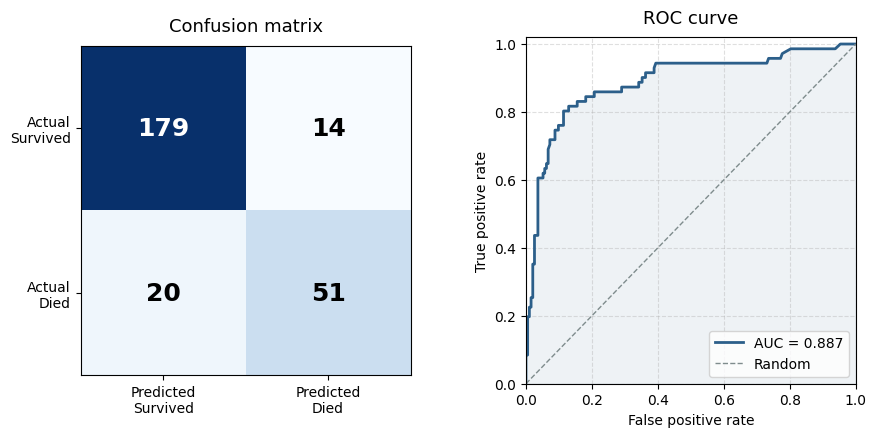

Saved fig_evaluation.png


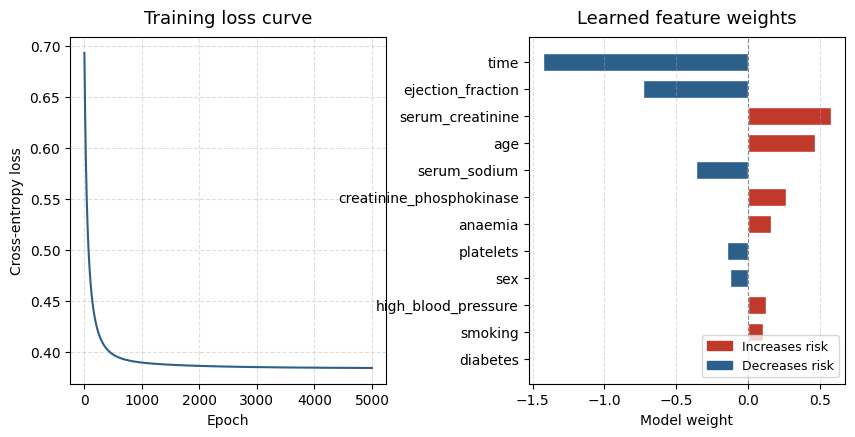

Saved fig_model.png

LaTeX table:

\begin{table}
  \caption{Model evaluation metrics on the held-out test set.}
  \label{tab:metrics}
  \begin{tabular}{lcc}
    \toprule
    Metric & Scratch LR & scikit-learn LR \\
    \midrule
    Accuracy & 0.8712 & 0.8674 \\
    Precision & 0.7846 & 0.7812 \\
    Recall & 0.7183 & 0.7042 \\
    F1-score & 0.7500 & 0.7407 \\
    ROC-AUC & 0.8872 & 0.8892 \\
    \bottomrule
  \end{tabular}
\end{table}


In [ ]:
# Claude was used to help design the visualizations and write the LaTeX table,
# but all plotting code and formatting were done by hand.
# ── figure 1: confusion matrix + ROC curve ────────────────────────────────

BLUE = '#2c5f8a'
RED  = '#c0392b'
GRAY = '#7f8c8d'

# reuse the already-computed values from the notebook
cm_array = np.array([[tn, fp], [fn, tp]])

# ROC points (reuse roc_auc_score_binary's internal curve)
thresholds = np.linspace(0, 1, 500)
tprs_roc, fprs_roc = [], []
for t in thresholds:
    p   = (test_probabilities >= t).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix_binary(y_test, p)
    tprs_roc.append(_tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0)
    fprs_roc.append(_fp / (_fp + _tn) if (_fp + _tn) > 0 else 0.0)
fprs_roc = np.array(fprs_roc)
tprs_roc = np.array(tprs_roc)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
fig1.subplots_adjust(wspace=0.35)

# Confusion matrix
ax1.imshow(cm_array, cmap='Blues')
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Predicted\nSurvived', 'Predicted\nDied'])
ax1.set_yticklabels(['Actual\nSurvived', 'Actual\nDied'])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm_array[i, j]), ha='center', va='center',
                 fontsize=18, fontweight='bold',
                 color='white' if cm_array[i, j] > cm_array.max() / 2 else 'black')
ax1.set_title('Confusion matrix', fontsize=13, pad=10)

# ROC curve
ax2.plot(fprs_roc, tprs_roc, color=BLUE, lw=2, label=f'AUC = {roc_auc:.3f}')
ax2.fill_between(fprs_roc, tprs_roc, alpha=0.08, color=BLUE)
ax2.plot([0, 1], [0, 1], color=GRAY, lw=1, linestyle='--', label='Random')
ax2.set_xlabel('False positive rate'); ax2.set_ylabel('True positive rate')
ax2.set_title('ROC curve', fontsize=13, pad=10)
ax2.legend(loc='lower right'); ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])

fig1.savefig('fig_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_evaluation.png')

# figure 2: loss curve + feature weights 

# recompute loss curve using the same hyperparameters
def compute_loss_curve(X, y, lr=0.03, epochs=5000):
    def sigmoid(z): return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    w = np.zeros(X.shape[1]); b = 0.0; losses = []
    for _ in range(epochs):
        p   = sigmoid(X @ w + b)
        p_c = np.clip(p, 1e-9, 1 - 1e-9)
        losses.append(-np.mean(y * np.log(p_c) + (1 - y) * np.log(1 - p_c)))
        w -= lr * (X.T @ (p - y) / len(y))
        b -= lr * np.mean(p - y)
    return losses

losses = compute_loss_curve(X_train, y_train)

# reuse the coefficient_table already built in the notebook
sorted_coef = coefficient_table.sort_values('absolute_value', ascending=True)

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(10, 4.5))
fig2.subplots_adjust(wspace=0.45)

# Training loss
ax3.plot(range(1, len(losses) + 1), losses, color=BLUE, lw=1.5)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Cross-entropy loss')
ax3.set_title('Training loss curve', fontsize=13, pad=10)
ax3.grid(True, linestyle='--', alpha=0.4)

# Feature weights
colors = [RED if v > 0 else BLUE for v in sorted_coef['coefficient']]
ax4.barh(sorted_coef['feature'], sorted_coef['coefficient'],
         color=colors, edgecolor='white', height=0.65)
ax4.axvline(0, color=GRAY, lw=0.8, linestyle='--')
ax4.set_xlabel('Model weight')
ax4.set_title('Learned feature weights', fontsize=13, pad=10)
ax4.grid(True, axis='x', linestyle='--', alpha=0.4)
from matplotlib.patches import Patch
ax4.legend(handles=[Patch(color=RED, label='Increases risk'),
                    Patch(color=BLUE, label='Decreases risk')],
           fontsize=9, loc='lower right')

fig2.savefig('fig_model.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_model.png')

# LaTeX metrics table
print("""
LaTeX table:

\\begin{table}
  \\caption{Model evaluation metrics on the held-out test set.}
  \\label{tab:metrics}
  \\begin{tabular}{lcc}
    \\toprule
    Metric & Scratch LR & scikit-learn LR \\\\
    \\midrule""")
for col, label in [('accuracy','Accuracy'),('precision','Precision'),
                    ('recall','Recall'),('f1_score','F1-score'),('roc_auc','ROC-AUC')]:
    scratch = comparison_table.loc[comparison_table['model']=='Scratch logistic regression', col].values[0]
    sklearn = comparison_table.loc[comparison_table['model']=='scikit-learn logistic regression', col].values[0]
    print(f"    {label} & {scratch:.4f} & {sklearn:.4f} \\\\")
print("""    \\bottomrule
  \\end{tabular}
\\end{table}""")